# Loading

In [1]:
import pandas as pd
import statsmodels.formula.api as smf
from statsmodels.stats.sandwich_covariance import cov_cluster
import numpy as np
import os
from tqdm import tqdm
import gc
from numba import njit
import duckdb
# Basic Models with just phase interaction
import sys
import statsmodels.formula.api as smf
from statsmodels.stats.sandwich_covariance import cov_cluster
from IPython.display import HTML
import numpy as np
import pandas as pd
from stargazer.stargazer import Stargazer

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

required_columns = [
    'numHelped',
    'phase',
    'hasAnswer',
    'userId',
    'userFeNumHelped',
    'numHelpProvidedAT',
    'userFeNumQuestionsAskedAT',
    'userFeNumHelpProvidedAT',
    'numQuestionsAskedAT',
    'logNumHelpProvidedAT',
    'logNumQuestionsAskedAT',
    'userFeLogNumHelpProvidedAT',
    'userFeLogNumQuestionsAskedAT',
]

df_reciprocity = pd.read_parquet('../data/study_datasets/question_centered_model_7d.parquet',
                    columns=required_columns)

required_columns = [
    'isBounty',
    'userFEIsBounty',
    'userId',
    'timeSinceFirstActivityDays',
    'logtimeSinceFirstActivityDays',
    'userFeLogTimeSinceFirstActivityDays',
    'numHelpProvidedAT',
    'numQuestionsAskedAT',
    'logNumHelpProvidedAT',
    'logNumQuestionsAskedAT',
    'userFeLogNumHelpProvidedAT',
    'userFeLogNumQuestionsAskedAT',
]

df_bounty = pd.read_parquet('../data/study_datasets/user_answers_bounty_processed.parquet', columns=required_columns)

# Filter and Re-calculate FEs

In [2]:
def filter_users_by_help_threshold(df, cutoff=5, verbose=True):
    """
    Filter dataset to users who have provided at least 'cutoff' help at some point,
    then keep only events where numHelpProvidedAT <= cutoff.
    """
        # Find users with max help >= cutoff
    user_max_help = df.groupby('userId')['numHelpProvidedAT'].max()
    included_users = user_max_help[user_max_help >= cutoff].index.tolist()

    # Filter to these users and events <= cutoff
    filtered_df = df[
        (df['userId'].isin(included_users)) &
        (df['numHelpProvidedAT'] <= cutoff)
    ].copy()

    filtered_df['numHelpProvidedAT_binned'] = filtered_df['numHelpProvidedAT']
    filtered_df['logNumQuestionsAskedAT'] = np.log(filtered_df['numQuestionsAskedAT'] + 1)
    filtered_df['userFeLogNumQuestionsAskedAT'] = filtered_df.groupby("userId")["logNumQuestionsAskedAT"].transform(
        lambda x: x - x.mean()
    )
    filtered_df['logNumHelpProvidedAT'] = np.log(filtered_df['numHelpProvidedAT'] + 1)
    filtered_df['userFelogNumHelpProvidedAT'] = filtered_df.groupby("userId")["logNumHelpProvidedAT"].transform(
        lambda x: x - x.mean()
    )

    if verbose:
        print(f"Cutoff: {cutoff}")
        print(f"Users included: {len(included_users):,}")
        print(f"Events: {len(filtered_df):,} ({len(filtered_df)/len(df):.1%} of original)")

    return filtered_df

print("=== RECIPROCITY DATASET ===")
df_reciprocity_filtered = filter_users_by_help_threshold(df_reciprocity, cutoff=5)
df_reciprocity_filtered['userFeNumHelped'] = df_reciprocity_filtered.groupby("userId")["numHelped"].transform(lambda x: x - x.mean())

print("\n=== BOUNTY DATASET ===")
df_bounty_filtered = filter_users_by_help_threshold(df_bounty, cutoff=5)
df_bounty_filtered['userFEIsBounty'] = df_bounty_filtered.groupby("userId")["isBounty"].transform(lambda x: x - x.mean())
df_bounty_filtered['logtimeSinceFirstActivityDays'] = np.log(df_bounty_filtered['timeSinceFirstActivityDays'] + 1)
df_bounty_filtered['userFeLogTimeSinceFirstActivityDays'] = df_bounty_filtered.groupby("userId")["logtimeSinceFirstActivityDays"].transform(lambda x: x - x.mean())

import gc
del df_reciprocity, df_bounty
gc.collect()

=== RECIPROCITY DATASET ===
Cutoff: 5
Users included: 411,508
Events: 5,821,370 (12.3% of original)

=== BOUNTY DATASET ===
Cutoff: 5
Users included: 608,910
Events: 3,653,460 (11.1% of original)


0

In [6]:
df_reciprocity_filtered.to_parquet('../data/study_datasets/question_centered_model_7d_5_NumHelp_filtered.parquet', index=False)
df_bounty_filtered.to_parquet('../data/study_datasets/user_answers_bounty_processed_5_NumHelp_filtered.parquet', index=False)

In [5]:
import pandas as pd
df_reciprocity_filtered = pd.read_parquet('../data/study_datasets/question_centered_model_7d_5_NumHelp_filtered.parquet')
df_reciprocity_filtered['logNumHelped'] = np.log(df_reciprocity_filtered['numHelped'] + 1)
df_bounty_filtered = pd.read_parquet('../data/study_datasets/user_answers_bounty_processed_5_NumHelp_filtered.parquet')

# 1. Plot Comparing

## 1.1 Reciprocity Binned Prediction

In [3]:
import statsmodels.formula.api as smf
from marginaleffects import predictions, datagrid

df_reciprocity_filtered['phase'] = df_reciprocity_filtered['phase'].astype(str)
df_reciprocity_filtered['hasAnswer'] = df_reciprocity_filtered['hasAnswer'].astype(str)
df_reciprocity_filtered['numHelpProvidedAT_binned'] = df_reciprocity_filtered['numHelpProvidedAT_binned'].astype(str)

formula1 = """userFeNumHelped ~ C(phase)*C(hasAnswer)*C(numHelpProvidedAT_binned) + logNumQuestionsAskedAT"""

model_rec = smf.ols(formula=formula1, data=df_reciprocity_filtered).fit(
    cov_type='cluster',
    cov_kwds={'groups': df_reciprocity_filtered['userId']}
)
print(model_rec.summary())

phase_level = "2"
hasAnswer_level = "1"
binned_levels = ["0", "1", "2", "3", "4", "5"]

grid = datagrid(
    model=model_rec,
    phase=phase_level,
    hasAnswer=hasAnswer_level,
    numHelpProvidedAT_binned=binned_levels
)

preds_rec = predictions(model_rec, newdata=grid)
print(preds_rec)
print(f"Mean of numHelped in dataset used is: {df_reciprocity_filtered['numHelped'].mean():.2f}")

                            OLS Regression Results                            
Dep. Variable:        userFeNumHelped   R-squared:                       0.008
Model:                            OLS   Adj. R-squared:                  0.008
Method:                 Least Squares   F-statistic:                     520.1
Date:                Mon, 02 Jun 2025   Prob (F-statistic):               0.00
Time:                        21:27:16   Log-Likelihood:            -1.0567e+07
No. Observations:             5821370   AIC:                         2.113e+07
Df Residuals:                 5821345   BIC:                         2.114e+07
Df Model:                          24                                         
Covariance Type:              cluster                                         
                                                                       coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------

## 1.2 Bounty Binned Prediction

In [4]:
import statsmodels.formula.api as smf
from marginaleffects import predictions, datagrid

df_bounty_filtered['numHelpProvidedAT_binned'] = df_bounty_filtered['numHelpProvidedAT_binned'].astype(str)

formula1 = """userFEIsBounty ~ C(numHelpProvidedAT_binned) + logNumQuestionsAskedAT + logtimeSinceFirstActivityDays"""

model_bounty = smf.ols(formula=formula1, data=df_bounty_filtered).fit(
    cov_type='cluster',
    cov_kwds={'groups': df_bounty_filtered['userId']}
)
print(model_bounty.summary())

binned_levels = ["0", "1", "2", "3", "4", "5"]

grid = datagrid(
    model=model_bounty,
    numHelpProvidedAT_binned=binned_levels
)

preds_bounty = predictions(model_bounty, newdata=grid)
print(preds_bounty)
print(f"Mean of isBounty in dataset used is: {df_bounty_filtered['isBounty'].mean():.2f}")

                            OLS Regression Results                            
Dep. Variable:         userFEIsBounty   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                     125.4
Date:                Mon, 02 Jun 2025   Prob (F-statistic):          4.12e-185
Time:                        21:28:12   Log-Likelihood:             3.4956e+06
No. Observations:             3653460   AIC:                        -6.991e+06
Df Residuals:                 3653452   BIC:                        -6.991e+06
Df Model:                           7                                         
Covariance Type:              cluster                                         
                                       coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
Intercep

# Create Plot

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


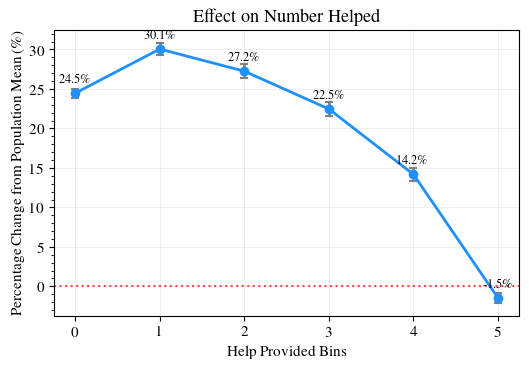

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


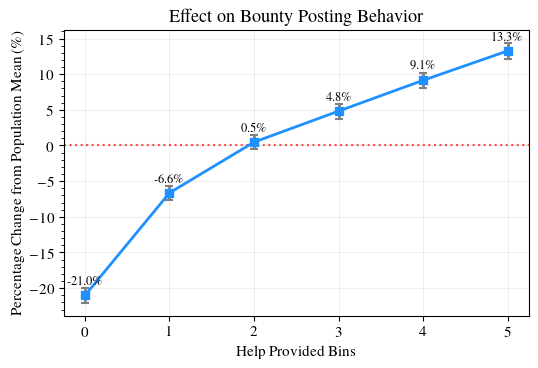


=== Summary Statistics ===
Population mean for numHelped: 0.467
Population mean for isBounty: 0.012

Percentage changes for numHelped model:
  Bin 0: 24.46\% ± 0.57\%
  Bin 1: 30.05\% ± 0.76\%
  Bin 2: 27.25\% ± 0.85\%
  Bin 3: 22.46\% ± 0.86\%
  Bin 4: 14.19\% ± 0.84\%
  Bin 5: -1.46\% ± 0.60\%

Percentage changes for isBounty model:
  Bin 0: -21.03\% ± 1.00\%
  Bin 1: -6.65\% ± 1.01\%
  Bin 2: 0.47\% ± 1.02\%
  Bin 3: 4.82\% ± 1.04\%
  Bin 4: 9.13\% ± 1.06\%
  Bin 5: 13.26\% ± 1.10\%


In [7]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.ticker as ticker


def set_size(width=433.62, fraction=1, equal_height_to_fraction_1=False):
    """Set figure dimensions to avoid scaling in LaTeX.

    Parameters:
    width: float
        Document textwidth or columnwidth in pts
    fraction: float
        Fraction of the width which you wish the figure to occupy
    equal_height_to_fraction_1: bool
        Whether to make the height the same as it would be for fraction=1
    """
    # Width of figure (in pts)
    fig_width_pt = width * fraction

    # Convert from pt to inches
    inches_per_pt = 1 / 72.27

    # Golden ratio to set aesthetic figure height
    golden_ratio = (5 ** 0.5 - 1) / 2

    # Figure width in inches
    fig_width_in = fig_width_pt * inches_per_pt

    if equal_height_to_fraction_1:
        # Use full width to calculate height if equal_height_to_fraction_1 is True
        fig_height_in = (width * inches_per_pt) * golden_ratio
    else:
        # Use current fraction to calculate height
        fig_height_in = fig_width_in * golden_ratio

    return (fig_width_in, fig_height_in)


def create_regression_plots():
    """
    Generate regression effect plots and save as EPS files.
    """

    # Set up LaTeX rendering and styling parameters
    plt.rcParams['text.latex.preamble'] = r"\usepackage{txfonts}"
    params = {
        'text.usetex': True,
        'font.size': 11,
        'font.family': 'serif',
    }
    plt.rcParams.update(params)

    # --- Extract data from existing predictions ---

    # Plot 1: userFeNumHelped Model
    # Population mean calculated dynamically
    population_mean_numHelped = df_reciprocity_filtered['numHelped'].mean()

    # Extract estimates and standard errors from preds_rec
    estimates_rec = preds_rec['estimate'].to_numpy()
    std_errors_rec = preds_rec['std_error'].to_numpy()

    # Calculate percentage change from population mean
    # Since the DV is demeaned, estimates are already deviations from the mean
    pct_change_rec = (estimates_rec / population_mean_numHelped) * 100
    # Convert standard errors to percentage change scale
    pct_se_rec = (std_errors_rec / population_mean_numHelped) * 100

    # Plot 2: userFEIsBounty Model
    # Population mean calculated dynamically
    population_mean_isBounty = df_bounty_filtered['isBounty'].mean()

    # Extract estimates and standard errors from preds_bounty
    estimates_bounty = preds_bounty['estimate'].to_numpy()
    std_errors_bounty = preds_bounty['std_error'].to_numpy()

    # Calculate percentage change from population mean
    # Since the DV is demeaned, estimates are already deviations from the mean
    pct_change_bounty = (estimates_bounty / population_mean_isBounty) * 100
    # Convert standard errors to percentage change scale
    pct_se_bounty = (std_errors_bounty / population_mean_isBounty) * 100

    # Bin labels
    binned_levels = ["0", "1", "2", "3", "4", "5"]
    x_positions = np.arange(len(binned_levels))

    # --- Create Plot 1: Number Helped ---
    fig1, ax1 = plt.subplots(figsize=set_size())

    ax1.errorbar(x_positions, pct_change_rec, yerr=pct_se_rec,
                 marker='o', capsize=3, capthick=1.5, linewidth=2, markersize=6,
                 color='dodgerblue', ecolor='gray', markerfacecolor='dodgerblue')

    ax1.set_xlabel('Help Provided Bins')
    ax1.set_ylabel('Percentage Change from Population Mean (\%)')
    ax1.set_title('Effect on Number Helped')
    ax1.set_xticks(x_positions)
    ax1.set_xticklabels(binned_levels)
    ax1.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)
    ax1.axhline(y=0, color='red', linestyle=':', alpha=0.7, linewidth=1.5)

    # Set y-axis with appropriate range and ticks
    y_min, y_max = ax1.get_ylim()
    y_range = y_max - y_min
    ax1.yaxis.set_minor_locator(ticker.AutoMinorLocator())

    # Add value labels on points
    for i, (pct, se) in enumerate(zip(pct_change_rec, pct_se_rec)):
        ax1.annotate(f'{pct:.1f}\%', (i, pct), textcoords="offset points",
                    xytext=(0,8), ha='center', fontsize=9)

    plt.savefig("regression_numhelped_effects.eps", dpi=1000, bbox_inches='tight')
    plt.show()

    # --- Create Plot 2: Is Bounty ---
    fig2, ax2 = plt.subplots(figsize=set_size())

    ax2.errorbar(x_positions, pct_change_bounty, yerr=pct_se_bounty,
                 marker='s', capsize=3, capthick=1.5, linewidth=2, markersize=6,
                 color='dodgerblue', ecolor='gray', markerfacecolor='dodgerblue')

    ax2.set_xlabel('Help Provided Bins')
    ax2.set_ylabel('Percentage Change from Population Mean (\%)')
    ax2.set_title('Effect on Bounty Posting Behavior')
    ax2.set_xticks(x_positions)
    ax2.set_xticklabels(binned_levels)
    ax2.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)
    ax2.axhline(y=0, color='red', linestyle=':', alpha=0.7, linewidth=1.5)

    # Set y-axis with appropriate range and ticks
    y_min, y_max = ax2.get_ylim()
    y_range = y_max - y_min
    ax2.yaxis.set_minor_locator(ticker.AutoMinorLocator())

    # Add value labels on points
    for i, (pct, se) in enumerate(zip(pct_change_bounty, pct_se_bounty)):
        ax2.annotate(f'{pct:.1f}\%', (i, pct), textcoords="offset points",
                    xytext=(0,8), ha='center', fontsize=9)

    plt.savefig("regression_bounty_effects.eps", dpi=1000, bbox_inches='tight')
    plt.show()

    # Print summary statistics
    print("\n=== Summary Statistics ===")
    print(f"Population mean for numHelped: {population_mean_numHelped:.3f}")
    print(f"Population mean for isBounty: {population_mean_isBounty:.3f}")
    print(f"\nPercentage changes for numHelped model:")
    for i, bin_val in enumerate(binned_levels):
        print(f"  Bin {bin_val}: {pct_change_rec[i]:.2f}\% ± {pct_se_rec[i]:.2f}\%")
    print(f"\nPercentage changes for isBounty model:")
    for i, bin_val in enumerate(binned_levels):
        print(f"  Bin {bin_val}: {pct_change_bounty[i]:.2f}\% ± {pct_se_bounty[i]:.2f}\%")


if __name__ == "__main__":
    create_regression_plots()

# Without FEs

=== RECIPROCITY MODEL (Log DV) ===
                            OLS Regression Results                            
Dep. Variable:           logNumHelped   R-squared:                       0.043
Model:                            OLS   Adj. R-squared:                  0.043
Method:                 Least Squares   F-statistic:                     1509.
Date:                Tue, 03 Jun 2025   Prob (F-statistic):               0.00
Time:                        12:11:25   Log-Likelihood:            -3.7878e+06
No. Observations:             5821370   AIC:                         7.576e+06
Df Residuals:                 5821345   BIC:                         7.576e+06
Df Model:                          24                                         
Covariance Type:              cluster                                         
                                                                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


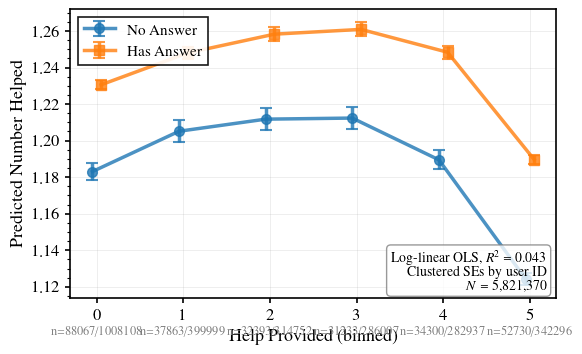

C:\Users\svenp\AppData\Local\Temp\ipykernel_5336\1634725397.py:297: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


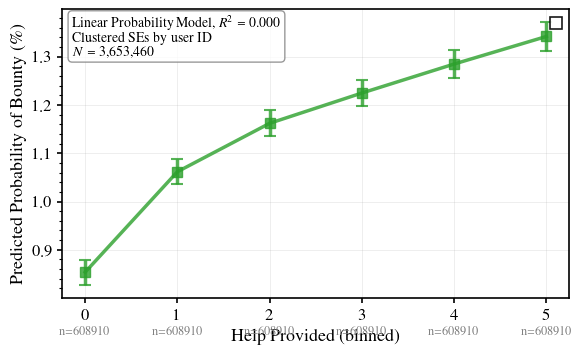


JOURNAL-QUALITY SUMMARY STATISTICS

Model 1: Log-linear OLS (log(Number Helped))
  R² = 0.043, N = 5,821,370
  Population mean: 0.467 people helped

Predicted values with 95% CIs (No Answer condition):
  Bin 0: 1.183 [1.179, 1.188] (n=88067)
  Bin 1: 1.205 [1.199, 1.211] (n=37863)
  Bin 2: 1.212 [1.206, 1.218] (n=32393)
  Bin 3: 1.212 [1.206, 1.218] (n=31233)
  Bin 4: 1.189 [1.184, 1.195] (n=34300)
  Bin 5: 1.124 [1.121, 1.128] (n=52730)

Predicted values with 95% CIs (Has Answer condition):
  Bin 0: 1.231 [1.228, 1.233] (n=1008108)
  Bin 1: 1.248 [1.245, 1.251] (n=399999)
  Bin 2: 1.258 [1.255, 1.262] (n=314752)
  Bin 3: 1.261 [1.257, 1.265] (n=286007)
  Bin 4: 1.248 [1.245, 1.252] (n=282937)
  Bin 5: 1.190 [1.187, 1.192] (n=342296)

Model 2: Linear Probability Model (Bounty Posting)
  R² = 0.000, N = 3,653,460
  Population mean: 0.012 (1.15%)

Predicted probabilities with 95% CIs:
  Bin 0: 0.85% [0.83%, 0.88%] (n=608910)
  Bin 1: 1.06% [1.04%, 1.09%] (n=608910)
  Bin 2: 1.16% [1.14%

In [19]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.ticker as ticker
import statsmodels.formula.api as smf
from marginaleffects import predictions, datagrid


def set_size(width=433.62, fraction=1, equal_height_to_fraction_1=False):
    """Set figure dimensions to avoid scaling in LaTeX.

    Parameters:
    width: float
        Document textwidth or columnwidth in pts
    fraction: float
        Fraction of the width which you wish the figure to occupy
    equal_height_to_fraction_1: bool
        Whether to make the height the same as it would be for fraction=1
    """
    # Width of figure (in pts)
    fig_width_pt = width * fraction

    # Convert from pt to inches
    inches_per_pt = 1 / 72.27

    # Golden ratio to set aesthetic figure height
    golden_ratio = (5 ** 0.5 - 1) / 2

    # Figure width in inches
    fig_width_in = fig_width_pt * inches_per_pt

    if equal_height_to_fraction_1:
        # Use full width to calculate height if equal_height_to_fraction_1 is True
        fig_height_in = (width * inches_per_pt) * golden_ratio
    else:
        # Use current fraction to calculate height
        fig_height_in = fig_width_in * golden_ratio

    return (fig_width_in, fig_height_in)


def run_regression_models():
    """
    Run the regression models and return predictions with sample sizes.
    """

    # --- Reciprocity Model (Log DV) ---
    print("=== RECIPROCITY MODEL (Log DV) ===")

    # Prepare data for reciprocity model
    df_reciprocity_filtered['phase'] = df_reciprocity_filtered['phase'].astype(str)
    df_reciprocity_filtered['hasAnswer'] = df_reciprocity_filtered['hasAnswer'].astype(str)
    df_reciprocity_filtered['numHelpProvidedAT_binned'] = df_reciprocity_filtered['numHelpProvidedAT_binned'].astype(str)

    # Define formula with log DV
    formula1 = """logNumHelped ~ C(phase)*C(hasAnswer)*C(numHelpProvidedAT_binned) + logNumQuestionsAskedAT"""

    # Fit model with clustered standard errors
    model_rec = smf.ols(formula=formula1, data=df_reciprocity_filtered).fit(
        cov_type='cluster',
        cov_kwds={'groups': df_reciprocity_filtered['userId']}
    )
    print(model_rec.summary())

    # Set up prediction grid for both hasAnswer conditions
    phase_level = "2"
    binned_levels = ["0", "1", "2", "3", "4", "5"]

    # Calculate sample sizes for each bin and condition
    sample_sizes = {}
    for has_answer in ["0", "1"]:
        sample_sizes[has_answer] = []
        for bin_level in binned_levels:
            mask = (
                (df_reciprocity_filtered['phase'] == phase_level) &
                (df_reciprocity_filtered['hasAnswer'] == has_answer) &
                (df_reciprocity_filtered['numHelpProvidedAT_binned'] == bin_level)
            )
            n = mask.sum()
            sample_sizes[has_answer].append(n)

    # Grid for hasAnswer = 0
    grid_rec_no_answer = datagrid(
        model=model_rec,
        phase=phase_level,
        hasAnswer="0",
        numHelpProvidedAT_binned=binned_levels
    )

    # Grid for hasAnswer = 1
    grid_rec_has_answer = datagrid(
        model=model_rec,
        phase=phase_level,
        hasAnswer="1",
        numHelpProvidedAT_binned=binned_levels
    )

    # Generate predictions for both conditions
    preds_rec_no_answer = predictions(model_rec, newdata=grid_rec_no_answer)
    preds_rec_has_answer = predictions(model_rec, newdata=grid_rec_has_answer)

    print("Predictions for hasAnswer=0:")
    print(preds_rec_no_answer)
    print("\nPredictions for hasAnswer=1:")
    print(preds_rec_has_answer)
    print(f"\nMean of numHelped in original dataset: {df_reciprocity_filtered['numHelped'].mean():.2f}")
    print(f"R-squared: {model_rec.rsquared:.3f}")
    print(f"N observations: {model_rec.nobs}")

    # --- Bounty Model (Linear Probability Model) ---
    print("\n=== BOUNTY MODEL (Linear Probability Model) ===")

    df_bounty_filtered['numHelpProvidedAT_binned'] = df_bounty_filtered['numHelpProvidedAT_binned'].astype(str)

    # Calculate sample sizes for bounty model
    bounty_sample_sizes = []
    for bin_level in binned_levels:
        mask = df_bounty_filtered['numHelpProvidedAT_binned'] == bin_level
        n = mask.sum()
        bounty_sample_sizes.append(n)

    formula2 = """isBounty ~ C(numHelpProvidedAT_binned) + logNumQuestionsAskedAT + logtimeSinceFirstActivityDays"""

    # Use linear model for predicted probabilities (Linear Probability Model)
    model_bounty = smf.ols(formula=formula2, data=df_bounty_filtered).fit(
        cov_type='cluster',
        cov_kwds={'groups': df_bounty_filtered['userId']}
    )
    print(model_bounty.summary())

    grid_bounty = datagrid(
        model=model_bounty,
        numHelpProvidedAT_binned=binned_levels
    )

    # Generate predictions (these are predicted probabilities)
    preds_bounty = predictions(model_bounty, newdata=grid_bounty)
    print("Predicted probabilities:")
    print(preds_bounty)
    print(f"Mean of isBounty in dataset: {df_bounty_filtered['isBounty'].mean():.3f}")
    print(f"R-squared: {model_bounty.rsquared:.3f}")
    print(f"N observations: {model_bounty.nobs}")

    return (preds_rec_no_answer, preds_rec_has_answer, preds_bounty, binned_levels,
            sample_sizes, bounty_sample_sizes, model_rec, model_bounty)


def create_regression_plots():
    """
    Generate journal-quality regression effect plots with 95% confidence intervals.
    """

    # Set up LaTeX rendering and styling parameters for journal quality
    plt.rcParams['text.latex.preamble'] = r"\usepackage{txfonts}"
    params = {
        'text.usetex': True,
        'font.size': 12,
        'font.family': 'serif',
        'axes.linewidth': 1.2,
        'xtick.major.width': 1.2,
        'ytick.major.width': 1.2,
        'xtick.minor.width': 0.8,
        'ytick.minor.width': 0.8,
    }
    plt.rcParams.update(params)

    # Run models and get predictions
    (preds_rec_no_answer, preds_rec_has_answer, preds_bounty, binned_levels,
     sample_sizes, bounty_sample_sizes, model_rec, model_bounty) = run_regression_models()

    # --- Plot 1: Predicted Number Helped (Both Conditions) with 95% CIs ---

    x_positions = np.arange(len(binned_levels))

    # Create Plot 1: Predicted Number Helped
    fig1, ax1 = plt.subplots(figsize=set_size())

    # Extract log predictions and compute 95% CIs correctly
    log_predictions_no = preds_rec_no_answer['estimate'].to_numpy()
    log_se_no = preds_rec_no_answer['std_error'].to_numpy()

    # Compute 95% CIs on log scale then transform
    log_ci_lower_no = log_predictions_no - 1.96 * log_se_no
    log_ci_upper_no = log_predictions_no + 1.96 * log_se_no

    # Transform to original scale
    predicted_numHelped_no = np.exp(log_predictions_no)
    ci_lower_no = np.exp(log_ci_lower_no)
    ci_upper_no = np.exp(log_ci_upper_no)

    # Asymmetric error bars
    yerr_lower_no = predicted_numHelped_no - ci_lower_no
    yerr_upper_no = ci_upper_no - predicted_numHelped_no

    ax1.errorbar(x_positions - 0.05, predicted_numHelped_no,
                 yerr=[yerr_lower_no, yerr_upper_no],
                 marker='o', capsize=4, capthick=1.5, linewidth=2.5, markersize=7,
                 color='#1f77b4', ecolor='#1f77b4', markerfacecolor='#1f77b4',
                 alpha=0.8, label='No Answer')

    # Same for has answer condition
    log_predictions_has = preds_rec_has_answer['estimate'].to_numpy()
    log_se_has = preds_rec_has_answer['std_error'].to_numpy()

    log_ci_lower_has = log_predictions_has - 1.96 * log_se_has
    log_ci_upper_has = log_predictions_has + 1.96 * log_se_has

    predicted_numHelped_has = np.exp(log_predictions_has)
    ci_lower_has = np.exp(log_ci_lower_has)
    ci_upper_has = np.exp(log_ci_upper_has)

    yerr_lower_has = predicted_numHelped_has - ci_lower_has
    yerr_upper_has = ci_upper_has - predicted_numHelped_has

    ax1.errorbar(x_positions + 0.05, predicted_numHelped_has,
                 yerr=[yerr_lower_has, yerr_upper_has],
                 marker='s', capsize=4, capthick=1.5, linewidth=2.5, markersize=7,
                 color='#ff7f0e', ecolor='#ff7f0e', markerfacecolor='#ff7f0e',
                 alpha=0.8, label='Has Answer')

    ax1.set_xlabel('Help Provided (binned)', fontsize=13)
    ax1.set_ylabel('Predicted Number Helped', fontsize=13)
    ax1.set_xticks(x_positions)
    ax1.set_xticklabels(binned_levels)
    ax1.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)

    # Set y-axis with appropriate range and ticks
    ax1.yaxis.set_minor_locator(ticker.AutoMinorLocator())

    # Add sample sizes as text below x-axis
    for i, bin_val in enumerate(binned_levels):
        n_no = sample_sizes["0"][i]
        n_has = sample_sizes["1"][i]
        ax1.text(i, ax1.get_ylim()[0] - 0.1 * (ax1.get_ylim()[1] - ax1.get_ylim()[0]),
                f'n={n_no}/{n_has}', ha='center', va='top', fontsize=9, color='gray')

    # Professional legend
    legend = ax1.legend(loc='upper left', frameon=True, fancybox=False,
                       edgecolor='black', framealpha=0.9, fontsize=11)
    legend.get_frame().set_linewidth(1.2)

    # Add model statistics as text box
    textstr = f'Log-linear OLS, $R^2$ = {model_rec.rsquared:.3f}\nClustered SEs by user ID\n$N$ = {int(model_rec.nobs):,}'
    props = dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='gray')
    ax1.text(0.98, 0.02, textstr, transform=ax1.transAxes, fontsize=10,
             verticalalignment='bottom', horizontalalignment='right', bbox=props)

    plt.tight_layout()
    plt.savefig("predicted_numhelped_by_answer_status.eps", dpi=300, bbox_inches='tight')
    plt.show()

    # --- Plot 2: Predicted Probabilities of Bounty Posting with 95% CIs ---

    # Extract predicted probabilities and compute 95% CIs
    predicted_probs_bounty = preds_bounty['estimate'].to_numpy()
    prob_std_errors_bounty = preds_bounty['std_error'].to_numpy()

    # Compute 95% CIs for probabilities
    ci_lower_bounty = predicted_probs_bounty - 1.96 * prob_std_errors_bounty
    ci_upper_bounty = predicted_probs_bounty + 1.96 * prob_std_errors_bounty

    # Ensure CIs are within [0,1] bounds
    ci_lower_bounty = np.maximum(ci_lower_bounty, 0)
    ci_upper_bounty = np.minimum(ci_upper_bounty, 1)

    # Convert to percentage scale
    predicted_probs_pct = predicted_probs_bounty * 100
    ci_lower_pct = ci_lower_bounty * 100
    ci_upper_pct = ci_upper_bounty * 100

    yerr_lower_bounty = predicted_probs_pct - ci_lower_pct
    yerr_upper_bounty = ci_upper_pct - predicted_probs_pct

    # Create Plot 2: Predicted Bounty Probabilities
    fig2, ax2 = plt.subplots(figsize=set_size())

    ax2.errorbar(x_positions, predicted_probs_pct,
                 yerr=[yerr_lower_bounty, yerr_upper_bounty],
                 marker='s', capsize=4, capthick=1.5, linewidth=2.5, markersize=7,
                 color='#2ca02c', ecolor='#2ca02c', markerfacecolor='#2ca02c',
                 alpha=0.8)

    ax2.set_xlabel('Help Provided (binned)', fontsize=13)
    ax2.set_ylabel('Predicted Probability of Bounty (\%)', fontsize=13)
    ax2.set_xticks(x_positions)
    ax2.set_xticklabels(binned_levels)
    ax2.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)

    # Set y-axis with appropriate range and ticks
    ax2.yaxis.set_minor_locator(ticker.AutoMinorLocator())

    # Add sample sizes below x-axis
    for i, (bin_val, n) in enumerate(zip(binned_levels, bounty_sample_sizes)):
        ax2.text(i, ax2.get_ylim()[0] - 0.1 * (ax2.get_ylim()[1] - ax2.get_ylim()[0]),
                f'n={n}', ha='center', va='top', fontsize=9, color='gray')

    # Professional legend
    legend = ax2.legend(loc='upper right', frameon=True, fancybox=False,
                       edgecolor='black', framealpha=0.9, fontsize=11)
    legend.get_frame().set_linewidth(1.2)

    # Add model statistics
    textstr = f'Linear Probability Model, $R^2$ = {model_bounty.rsquared:.3f}\nClustered SEs by user ID\n$N$ = {int(model_bounty.nobs):,}'
    props = dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='gray')
    ax2.text(0.02, 0.98, textstr, transform=ax2.transAxes, fontsize=10,
             verticalalignment='top', horizontalalignment='left', bbox=props)

    plt.tight_layout()
    plt.savefig("predicted_bounty_prob_by_bin.eps", dpi=300, bbox_inches='tight')
    plt.show()

    # Print journal-quality summary statistics
    print("\n" + "="*80)
    print("JOURNAL-QUALITY SUMMARY STATISTICS")
    print("="*80)

    print(f"\nModel 1: Log-linear OLS (log(Number Helped))")
    print(f"  R² = {model_rec.rsquared:.3f}, N = {int(model_rec.nobs):,}")
    print(f"  Population mean: {df_reciprocity_filtered['numHelped'].mean():.3f} people helped")

    print(f"\nPredicted values with 95% CIs (No Answer condition):")
    for i, bin_val in enumerate(binned_levels):
        print(f"  Bin {bin_val}: {predicted_numHelped_no[i]:.3f} [{ci_lower_no[i]:.3f}, {ci_upper_no[i]:.3f}] (n={sample_sizes['0'][i]})")

    print(f"\nPredicted values with 95% CIs (Has Answer condition):")
    for i, bin_val in enumerate(binned_levels):
        print(f"  Bin {bin_val}: {predicted_numHelped_has[i]:.3f} [{ci_lower_has[i]:.3f}, {ci_upper_has[i]:.3f}] (n={sample_sizes['1'][i]})")

    print(f"\nModel 2: Linear Probability Model (Bounty Posting)")
    print(f"  R² = {model_bounty.rsquared:.3f}, N = {int(model_bounty.nobs):,}")
    print(f"  Population mean: {df_bounty_filtered['isBounty'].mean():.3f} ({df_bounty_filtered['isBounty'].mean()*100:.2f}%)")

    print(f"\nPredicted probabilities with 95% CIs:")
    for i, bin_val in enumerate(binned_levels):
        print(f"  Bin {bin_val}: {predicted_probs_pct[i]:.2f}% [{ci_lower_pct[i]:.2f}%, {ci_upper_pct[i]:.2f}%] (n={bounty_sample_sizes[i]})")

    # Effect size analysis
    print(f"\n" + "="*50)
    print("EFFECT SIZE ANALYSIS")
    print("="*50)

    # Cohen's d equivalent for differences from baseline
    baseline_no = predicted_numHelped_no[0]
    baseline_has = predicted_numHelped_has[0]

    print(f"\nEffect sizes (difference from Bin 0, in population SDs):")
    pop_sd = df_reciprocity_filtered['numHelped'].std()

    for i, bin_val in enumerate(binned_levels[1:], 1):  # Skip bin 0
        effect_no = (predicted_numHelped_no[i] - baseline_no) / pop_sd
        effect_has = (predicted_numHelped_has[i] - baseline_has) / pop_sd
        print(f"  Bin {bin_val}: No Answer = {effect_no:.3f}σ, Has Answer = {effect_has:.3f}σ")


if __name__ == "__main__":
    create_regression_plots()